1. What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.
  - Deep Learning is a subset of machine learning which uses artificial neural networks to learn complex data patterns.
  - Evolution:
    - Idea of perceptron
    - Backward propagation
    - Increase in computation power (GPU).
  - Traditional ML requires human-designed features.
  - DL can learn from raw data.

2. Explain the basic architecture and functioning of a Perceptron. What are its limitations?
  - Perceptron is the simplest type of neural network used for binary classification.
  - Functioning:
    - Inputs are given to the model.
    - Each input is multiplied by its weight.
    - The weighted values are summed and bias is added.
    - The result passes through an activation function (step function).
    - The output is 0 or 1, representing the predicted class.
    - During training, weights are adjusted using a learning rule to reduce errors.
  - Limitations of Perceptron:
    - Cannot solve non linear problems.

3. Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.
  - An activation function determines whether a neuron should be activated or not. It introduces non-linearity into the neural network, allowing the model to learn complex patterns in the data.
  - Sigmoid: Used when output is binary.
  - ReLU: Used in hidden layers in modern neural networks.
  - Tanh: Used in hidden layers during older neural networks.

4. What is the difference between Loss function and Cost function in neural networks? Provide examples.
  - Loss function: error for one data point.
  - E.g. (actual - predicted)²
  - Cost function: average loss over the whole dataset used to train the neural network.
  - E.g. 1/n(sum(actual - predicted)²)

5. What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.
  - An optimizer is an algorithm used to update the weights and biases of a neural network to minimize the loss (or cost) function during training.
  - Gradient Descent:
    - Simple but may be slow and sensitive to learning rate.
  - RMSprop (Root Mean Square Propagation)
    - Adjusts learning rate based on recent gradients.
    - Works well for non-stationary problems and deep networks.
  - Adam (Adaptive Moment Estimation)
    - Combines momentum and RMSprop.
    - Uses moving averages of gradients and squared gradients.
    - Most commonly used optimizer in deep learning.

In [10]:
# 6. Write a Python program to implement a single-layer perceptron from
# scratch using NumPy to solve the logical AND gate.
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

# Model
model = Sequential()
model.add(Dense(1, input_dim=2, activation='sigmoid'))

# Compile
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(X, y, epochs=100, verbose=0)

# Predictions
predictions = model.predict(X)
print("Predictions:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predictions:
[[0.39218175]
 [0.6695449 ]
 [0.6347058 ]
 [0.845108  ]]


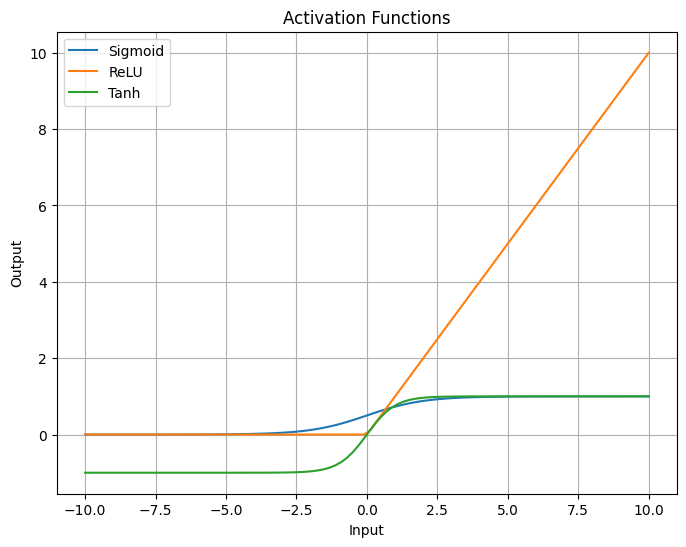

In [11]:
# 7.  Implement and visualize Sigmoid, ReLU, and Tanh activation functions
# using Matplotlib.
import numpy as np
import matplotlib.pyplot as plt

# Create input values
x = np.linspace(-10, 10, 100)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# Compute outputs
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_tanh = tanh(x)

# Plot graphs
plt.figure(figsize=(8,6))

plt.plot(x, y_sigmoid, label="Sigmoid")
plt.plot(x, y_relu, label="ReLU")
plt.plot(x, y_tanh, label="Tanh")

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid()

plt.show()

In [1]:
# 8.  Use Keras to build and train a simple multilayer neural network on the
# MNIST digits dataset. Print the training accuracy.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build model
model = Sequential([
    Flatten(input_shape=(28, 28)),   # Convert 2D image to 1D vector
    Dense(128, activation='relu'),   # Hidden layer
    Dense(64, activation='relu'),    # Hidden layer
    Dense(10, activation='softmax')  # Output layer (10 digits)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(X_train, y_train, epochs=5, batch_size=32)

# Print training accuracy
print("Training Accuracy:", history.history['accuracy'][-1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8791 - loss: 0.4163
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9676 - loss: 0.1040
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9776 - loss: 0.0721
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9841 - loss: 0.0497
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9866 - loss: 0.0397
Training Accuracy: 0.9855499863624573


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7443 - loss: 0.7280 - val_accuracy: 0.8497 - val_loss: 0.4229
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8562 - loss: 0.4023 - val_accuracy: 0.8638 - val_loss: 0.3833
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8716 - loss: 0.3529 - val_accuracy: 0.8720 - val_loss: 0.3600
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8802 - loss: 0.3251 - val_accuracy: 0.8692 - val_loss: 0.3653
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8861 - loss: 0.3095 - val_accuracy: 0.8787 - val_loss: 0.3339
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8955 - loss: 0.2811 - val_accuracy: 0.8737 - val_loss: 0.3480
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3

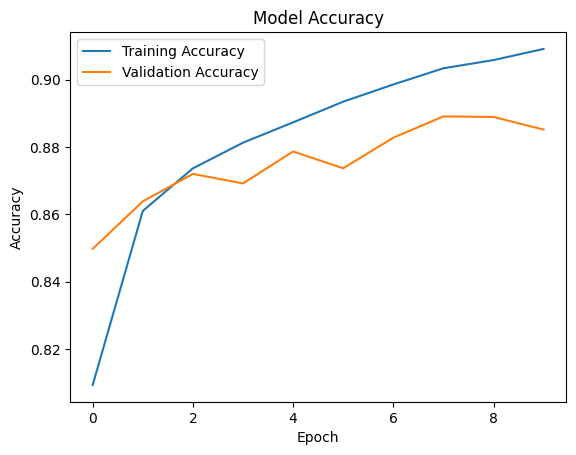

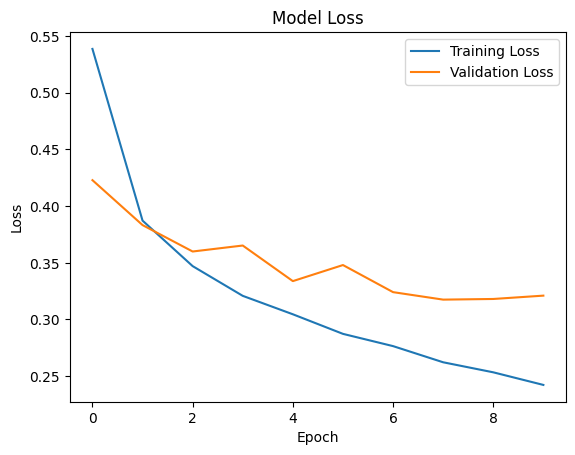

In [2]:
# 9.  Visualize the loss and accuracy curves for a neural network model trained
# on the Fashion MNIST dataset. Interpret the training behavior.
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build neural network
model = Sequential([
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=64)

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# 10. You are working on a project for a bank that wants to automatically detect
# fraudulent transactions. The dataset is large, imbalanced, and contains structured
# features like transaction amount, merchant ID, and customer location. The goal is to
# classify each transaction as fraudulent or legitimate.
# Explain your real-time data science workflow:
# ● How would you design a deep learning model (perceptron or multilayer NN)?
# ● Which activation function and loss function would you use, and why?
# ● How would you train and evaluate the model, considering class imbalance?
# ● Which optimizer would be suitable, and how would you prevent overfitting?

- I will choose multilayer NN, because it can solve non linear and complex problems.
- In hidden layer, Relu. Because it's better.
- In output layer, sigmoid. Because there is only 2 output.
- binary cross entropy for loss function.
- NN can give more weights to less class or i can use smote.
- I will evaluate the model using accuracy metrics.
- Adam optimizer.
- Dropout and EarlyStopping can be used to stop overfitting.